In [1]:
import os
import numpy as np
from PIL import Image

# Criando a estrutura exigida de pastas no ambiente Linux do Google
os.makedirs("dataset_satelite/train/incendio", exist_ok=True)
os.makedirs("dataset_satelite/train/floresta", exist_ok=True)
os.makedirs("dataset_satelite/validation/incendio", exist_ok=True)
os.makedirs("dataset_satelite/validation/floresta", exist_ok=True)

# Função para gerar imagens aleatórias (Simulando o tamanho 128x128)
def gerar_imagens_artificiais(pasta, qtd, cor_predominante):
    for i in range(qtd):
        if cor_predominante == 'vermelho': # Simula incêndio/calor
            matriz = np.random.randint(150, 255, (128, 128, 3), dtype=np.uint8)
            matriz[:, :, 1] = np.random.randint(0, 50, (128, 128)) # Baixo verde
        else: # Simula floresta estável
            matriz = np.random.randint(0, 50, (128, 128, 3), dtype=np.uint8)
            matriz[:, :, 1] = np.random.randint(120, 255, (128, 128)) # Alto verde

        img = Image.fromarray(matriz)
        img.save(f"{pasta}/img_{i}.jpg")

print("[INFO] Criando dataset espacial sintético...")
gerar_imagens_artificiais("dataset_satelite/train/incendio", 60, 'vermelho')
gerar_imagens_artificiais("dataset_satelite/train/floresta", 60, 'verde')
gerar_imagens_artificiais("dataset_satelite/validation/incendio", 20, 'vermelho')
gerar_imagens_artificiais("dataset_satelite/validation/floresta", 20, 'verde')
print("[SUCESSO] Dataset pronto para o treinamento das CNNs!")

[INFO] Criando dataset espacial sintético...
[SUCESSO] Dataset pronto para o treinamento das CNNs!


Found 120 files belonging to 2 classes.
Found 40 files belonging to 2 classes.

[IA] Treinando Arquitetura 1 (CNN Simples)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9750 - loss: 0.0539 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0

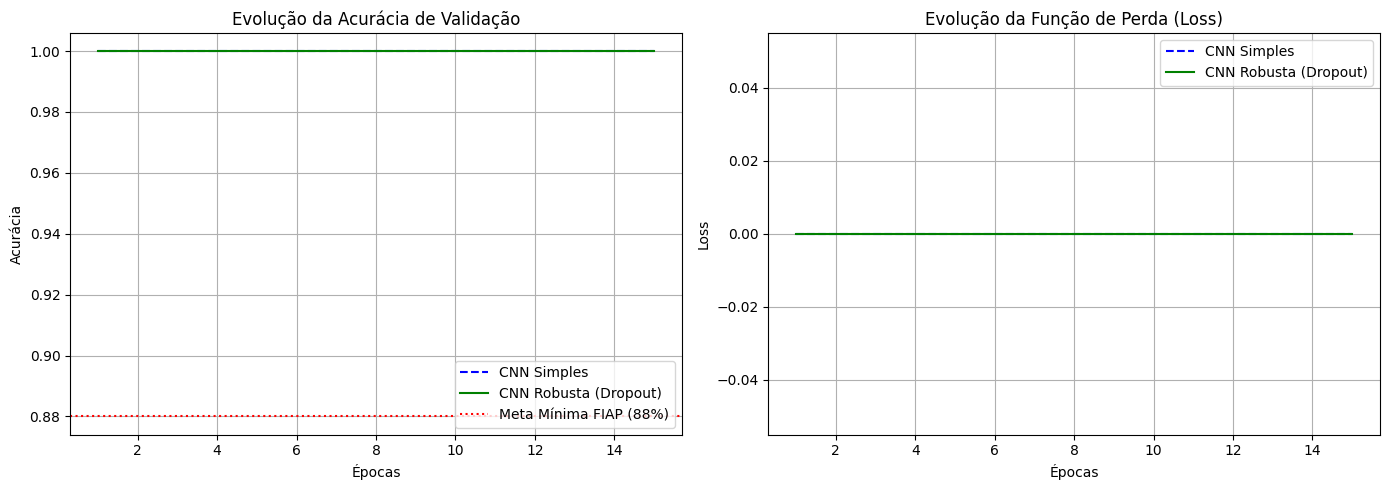

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

PASTA_DATASET = "dataset_satelite"
IMG_ALTURA, IMG_LARGURA = 128, 128
BATCH_SIZE = 8
EPOCHS = 15

# Carregando os dados das pastas criadas
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PASTA_DATASET, "train"),
    image_size=(IMG_ALTURA, IMG_LARGURA),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PASTA_DATASET, "validation"),
    image_size=(IMG_ALTURA, IMG_LARGURA),
    batch_size=BATCH_SIZE
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================
# 🚀 CNN 1: MODELO SIMPLES (Criada do Zero)
# ==========================================
print("\n[IA] Treinando Arquitetura 1 (CNN Simples)...")
modelo_simples = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_ALTURA, IMG_LARGURA, 3)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)
])

modelo_simples.compile(optimizer='adam',
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

historico_simples = modelo_simples.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# ==========================================
# 🚀 CNN 2: MODELO ROBUSTO (Com Dropout para evitar erros)
# ==========================================
print("\n[IA] Treinando Arquitetura 2 (CNN Robusta com Dropout)...")
modelo_robusto = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_ALTURA, IMG_LARGURA, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3), # Força as conexões neurais a ficarem mais inteligentes
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2)
])

modelo_robusto.compile(optimizer='adam',
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

historico_robusto = modelo_robusto.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# ==========================================
# 📊 GRÁFICOS DE COMPARAÇÃO EXIGIDOS NA DEMANDA
# ==========================================
acc_s = historico_simples.history['val_accuracy']
acc_r = historico_robusto.history['val_accuracy']
loss_s = historico_simples.history['val_loss']
loss_r = historico_robusto.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_s, label='CNN Simples', color='blue', linestyle='--')
plt.plot(epochs_range, acc_r, label='CNN Robusta (Dropout)', color='green')
plt.axhline(y=0.88, color='red', linestyle=':', label='Meta Mínima FIAP (88%)')
plt.title('Evolução da Acurácia de Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_s, label='CNN Simples', color='blue', linestyle='--')
plt.plot(epochs_range, loss_r, label='CNN Robusta (Dropout)', color='green')
plt.title('Evolução da Função de Perda (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.savefig("comparacao_modelos_cnn.png")
plt.show()